# Classic models (raw audio) — vodič kroz notebook

> MIDI/simbolički pristup je izdvojen u poseban notebook: `classic_models_midi.ipynb`.

Ovaj notebook pokušava da prepozna **kompozitora klasičnog muzičkog djela na osnovu audio zapisa**.
Ideja je da se audio prvo podijeli na segmente, iz svakog segmenta izdvoje numerički atributi, a zatim da se
isprobaju klasični modeli: **Logistic Regression, RBF SVM, KNN i Random Forest**.

## Tok rada

1. Učitava se MusicNet metadata tabela.
2. Formira se `work_id` da bi svi stavovi istog djela bili tretirani kao jedna grupa.
3. Zadržavaju se kompozitori sa najmanje 5 različitih djela.
4. Audio se dijeli na segmente od 25 s; posljednji segment se zadržava samo ako traje najmanje 10 s.
5. Za svaki segment se izračunavaju audio atributi (`MFCC`, `chroma`, spectral centroid, bandwidth, rolloff, RMS).
6. Modeli se porede pomoću `StratifiedGroupKFold`.
7. Predikcije segmenata jednog djela spajaju se u jednu predikciju za cijelo djelo.
8. Kao glavna metrika prati se **macro F1**, jer skup nije balansiran po kompozitorima.

## Zašto je `groups = work_id` veoma važno?

Više audio-segmenata potiče iz istog djela i zato su međusobno jako slični. Ako bi segmenti istog djela završili
i u treningu i u validaciji, model bi mogao da prepozna konkretno djelo umjesto stila kompozitora. Zato
`StratifiedGroupKFold` drži sve segmente jednog `work_id` u istom foldu.

## Kako čitati rezultate?

- **accuracy** = procenat svih djela koja su tačno klasifikovana;
- **macro F1** = F1 se računa za svakog kompozitora posebno, pa se uzima prost prosjek; zato manjinske klase
  imaju isti značaj kao Beethoven ili Bach;
- **classification report** pokazuje precision, recall i F1 za svaku klasu;
- **confusion matrix** pokazuje koje kompozitore model najčešće miješa.

> **Napomena o refaktoringu:** `extract_features`, `make_dataset`, `make_sample_weights`,
> `majority_vote_prediction` i `soft_vote_predictions` su izdvojeni u module (`feature_engineering.py`,
> `dataset.py`, `evaluation.py`) i uvoze se na početku odgovarajuće sekcije. Time je otklonjen raniji problem
> gdje je `make_sample_weights` bila definisana tek u odjeljku "Popravljanje modela", a korišćena ranije u
> Logistic Regression i SVM dijelu — čist `Restart Kernel -> Run All` sada radi bez `NameError`.

# Funkcija za ekstrakciju atributa

U ovom dijelu se svaki audio-segment pretvara u numerički vektor atributa koji klasični ML modeli mogu da koriste.
Umjesto da model direktno dobije desetine hiljada audio uzoraka, iz segmenta izdvajamo sažet opis njegovog
spektralnog i harmonskog sadržaja.


## Šta predstavljaju izdvojeni atributi?

`extract_features(segment, sr)` (iz `feature_engineering.py`) pretvara jedan audio-segment u vektor od
**147 brojeva**. Redoslijed je fiksiran i tačno prati `feature_names()` iz istog modula — to je bitno za
feature importance plot niže u notebook-u.

- **STFT** razlaže signal na frekvencijski sadržaj kroz vrijeme. Iz njega se jednom računaju `magnitude` i `power`
  da se isti skupi proračun ne bi ponavljao za svaki atribut.
- **MFCC (20 koeficijenata, mean+std)** opisuju oblik spektralnog omotača / boju zvuka.
- **Delta MFCC (mean+std)** — prvi izvod MFCC-a kroz vrijeme; opisuje koliko brzo se mijenja boja zvuka
  (artikulacija — legato naspram staccato).
- **Chroma (12 tonskih klasa, mean+std)** opisuje koliko su zastupljene tonske klase C, C#, D, ... bez obzira
  na oktavu; korisna je za harmoniju i tonalitet.
- **Tonnetz (6 dimenzija, mean+std)** — projekcija chrome u prostor harmonskih relacija (kvinte, terce);
  opisuje harmonski "jezik" — konsonancu/disonancu, blizinu akorada.
- **Spectral centroid** — "težište" spektra; veće vrijednosti često odgovaraju svjetlijem zvuku.
- **Spectral bandwidth** — koliko je spektar raširen oko centroida.
- **Spectral rolloff** — granica ispod koje se nalazi najveći dio spektralne energije.
- **Spectral contrast (7 opsega, mean+std)** — razlika između vrhova i dolina spektra po frekventnim
  opsezima; opisuje "bogatstvo" orkestracije (solo instrument naspram punog ansambla).
- **Spectral flatness (mean+std)** — koliko spektar liči na bijeli šum naspram čistog tona.
- **Zero-crossing rate (mean+std)** — koliko puta signal mijenja predznak; grubost/perkusivnost zvuka.
- **RMS** mjeri energiju / jačinu signala.
- **Tempo + onset strength (mean+std)** — procijenjeni tempo i gustina "napada" nota kroz vrijeme;
  ritmička gustina.
- **Harmonic/percussive ratio + percussive RMS** — udio pjevljivog/legato sadržaja naspram
  napadnog/artikulisanog, dobijen razdvajanjem signala (`librosa.effects.hpss`).

Na kraju se sve vrijednosti spajaju u jedan `np.float32` vektor koji postaje jedan red matrice `X`.

> Sa 147 dimenzija na svega ~113 djela, dimenzionalnost je sad znatno veća nego prije (72). Zato je važno
> nakon treniranja provjeriti feature importance (sekcija poslije Random Forest-a) — da se vidi da li novi
> atributi stvarno doprinose ili samo dodaju šum/rizik od overfittinga.


In [61]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from src.features.feature_engineering import extract_features

import logging

logging.basicConfig(level=logging.INFO, format="%(name)s - %(levelname)s - %(message)s")

# Ucitavanje podataka

## Učitavanje i pregled metapodataka

`metadata` je tabela u kojoj svaki red opisuje jedan audio zapis / stav: kompozitora, djelo, stav, ansambl,
trajanje itd. Naredne ćelije prvo provjeravaju nedostajuće vrijednosti i spisak kompozitora, a tek onda
odlučuju koje klase ostaju u eksperimentu.

Putanje `AUDIO_DIR` i `METADATA_PATH` su lokalne putanje sa računara na kojem je notebook pisan; na drugom
računaru moraju da pokazuju na odgovarajuću lokaciju MusicNet fajlova.


In [63]:
import numpy as np
import pandas as pd

from src.utils.paths import AUDIO_DIR, METADATA_PATH

metadata = pd.read_csv(METADATA_PATH)

print(metadata.head())
print(metadata.columns)

     id  composer               composition                   movement  \
0  1727  Schubert  Piano Quintet in A major                 2. Andante   
1  1728  Schubert  Piano Quintet in A major         3. Scherzo: Presto   
2  1729  Schubert  Piano Quintet in A major  4. Andantino - Allegretto   
3  1730  Schubert  Piano Quintet in A major          5. Allegro giusto   
4  1733  Schubert   Piano Sonata in A major               2. Andantino   

        ensemble            source                      transcriber  \
0  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
1  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
2  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
3  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
4     Solo Piano          Museopen                Segundo G. Yogore   

  catalog_name  seconds  
0        OP114      447  
1        OP114      251  
2        OP114      444  
3        OP114      368 

In [64]:
metadata.isna().sum()
# No missing values

id              0
composer        0
composition     0
movement        0
ensemble        0
source          0
transcriber     0
catalog_name    0
seconds         0
dtype: int64

In [65]:
metadata["composer"].unique()
# We have 10 composers

<StringArray>
[ 'Schubert',    'Mozart',    'Dvorak',   'Cambini',     'Haydn',    'Brahms',
     'Faure',     'Ravel',      'Bach', 'Beethoven']
Length: 10, dtype: str

## Zašto se pravi `work_id`?

Jedno muzičko djelo može imati više stavova, a u metapodacima su oni posebni redovi. Kombinacijom
`composer + composition` pravi se identifikator cijelog djela. Tako npr. više stavova iste sonate ostaju ista
grupa tokom cross-validationa.

Nakon toga se broji broj **različitih djela po kompozitoru**, ne broj segmenata. Kompozitori sa manje od 5
djela se uklanjaju jer bi grupni cross-validation za njih bio vrlo nestabilan.


In [66]:
metadata["work_id"] = (
    metadata["composer"].astype(str)
    + " | "
    + metadata["composition"].astype(str)
)

# Adding a column so we can group the same composition from different movements

In [67]:
work_counts = (
    metadata.groupby("composer")["work_id"]
    .nunique()
)

print(work_counts)

# We will remove all the composers that have less than 5 compositions in the dataset, also we can see our dataset is inbalanced

composer
Bach         30
Beethoven    55
Brahms        8
Cambini       3
Dvorak        2
Faure         1
Haydn         1
Mozart       11
Ravel         1
Schubert      9
Name: work_id, dtype: int64


In [68]:
valid_composers = work_counts[
    work_counts >= 5
].index

metadata_filtered = metadata[
    metadata["composer"].isin(valid_composers)
].copy()

# Filtering the composers

In [69]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


## Formiranje skupa `X, y, groups`

`make_dataset` prolazi kroz svaki izabrani audio zapis:

- učita `.npy` audio;
- dijeli ga na odsječke dužine `segment_duration`;
- odbacuje posljednji odsječak ako je kraći od `min_last_duration`;
- za svaki zadržani segment poziva `extract_features`;
- u `X` stavlja vektor atributa;
- u `y` stavlja ime kompozitora;
- u `groups` stavlja `work_id`.

Zato važi:

- `X[i]` = atributi jednog audio-segmenta,
- `y[i]` = kompozitor tog segmenta,
- `groups[i]` = djelo iz kojeg je segment izrezan.

U narednoj ćeliji su konkretno izabrani segmenti od **25 s**, a posljednji se čuva ako ima najmanje **10 s**.
Iz prikazanog outputa vidi se da je obrada 302 zapisa trajala oko 21 minut, pa ovu ćeliju nije potrebno
bez potrebe ponavljati.


In [70]:
from src.features.dataset import make_dataset

In [ ]:
import librosa

X, y, groups = make_dataset(
    metadata_filtered,
    AUDIO_DIR,
    # sr = 44100,
    # segment_duration = 25,
    # min_last_duration = 10,
)

NameError: name 'make_dataset_grouped' is not defined

In [ ]:
X

array([[-6.4282703e+02,  2.0397926e+02,  2.1716084e+01, ...,
         2.9845884e-01,  8.6149490e-01,  3.9321897e-03],
       [-5.9822467e+02,  2.0377849e+02,  7.4200158e+00, ...,
         2.4861534e-01,  8.5080975e-01,  2.8261286e-03],
       [-5.5706580e+02,  2.0682599e+02, -1.2000908e+01, ...,
         2.7603990e-01,  8.6647105e-01,  3.5755760e-03],
       ...,
       [-6.7928729e+02,  2.0843530e+02,  3.6351826e+01, ...,
         7.0522708e-01,  8.7629467e-01,  3.5220247e-03],
       [-6.6007452e+02,  2.1609648e+02,  2.1979774e+01, ...,
         8.1488043e-01,  8.6069810e-01,  4.1290163e-03],
       [-7.4219434e+02,  1.6151054e+02,  4.2114494e+01, ...,
         7.3584026e-01,  8.8336200e-01,  1.7657641e-03]],
      shape=(11096, 109), dtype=float32)

---

## Zajednički princip evaluacije modela

Za sve klasične modele želimo da mjerimo sposobnost generalizacije na **nova djela**, a ne samo na nove
segmente poznatog djela.

`StratifiedGroupKFold(n_splits=5)` pokušava istovremeno da:

1. drži sve segmente istog `work_id` zajedno;
2. približno očuva raspodjelu kompozitora po foldovima.

`StandardScaler` se kod Logistic Regression, SVM i KNN stavlja u `Pipeline`, tako da se skaler fituje samo
na trening dio svakog folda. To je važno da informacije iz validacionog folda ne procure u trening.


# Logisticka regresija

In [ ]:
from sklearn import preprocessing, metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline

from src.model.evaluation import make_sample_weights, majority_vote_prediction, soft_vote_predictions

KeyError: '__reduce_cython__'

In [ ]:
sgkf = StratifiedGroupKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [ ]:
C_values = [10 ** i for i in range(-3,3)]
results = []


### Od segmenta do predikcije cijelog djela

Model tehnički predviđa klasu **svakog segmenta**, ali konačna jedinica evaluacije je cijelo djelo.
`majority_vote_prediction` uzima sve segmente jednog `work_id` i bira kompozitora koji je dobio najviše
glasova.

Primjer: ako pet segmenata istog djela daju

`[Bach, Bach, Mozart, Bach, Beethoven]`

konačna predikcija djela je `Bach`.

`work_true` i `work_pred` zato imaju po **jedan element po djelu**, a accuracy i macro F1 se računaju nad
djelima.


### Logistic Regression — izbor hiperparametra `C`

Petlja ispituje više vrijednosti `C`. U logističkoj regresiji:

- manje `C` = jača regularizacija;
- veće `C` = slabija regularizacija.

Za svaku vrijednost se radi svih 5 foldova, predikcije segmenata se pretvaraju u work-level predikcije,
pa se računaju srednji accuracy i macro F1. `best` se zatim bira po **macro F1**, što ima smisla zbog
neravnoteže klasa.

`sample_weights` pokušava da spriječi da kompozitor sa mnogo djela ili djelo sa mnogo segmenata dominira
lossom: ukupna težina se ravnomjernije raspoređuje po kompozitorima i djelima.


In [ ]:
import time

grid_start_time = time.time()

for C in C_values:

    work_acc_scores = []
    work_f1_scores = []
    for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X,y,groups),
        start = 1
    ):
        
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        groups_train = groups[train_idx]
    
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
    
        groups_val = groups[val_idx]

        sample_weights = make_sample_weights(
            y_train_fold,
            groups_train
        )
    
        model = make_pipeline(
            preprocessing.StandardScaler(),
    
            LogisticRegression(
                C = C,
                max_iter = 20000,
                class_weight = None
            )
        )
    
        model.fit(
            X_train_fold,
            y_train_fold,
            logisticregression__sample_weight = sample_weights
        )
    
        pred = model.predict(X_val_fold)
    
        work_true, work_pred = majority_vote_prediction(
            y_val_fold,
            pred,
            groups_val
        )
    
        work_accuracy = metrics.accuracy_score(
            work_true,
            work_pred
        )
    
        work_f1 = metrics.f1_score(
            work_true,
            work_pred,
            average = "macro"
        )
    
        work_acc_scores.append(work_accuracy)
        work_f1_scores.append(work_f1)
    
        print(
            f"Fold {fold}: "
            f"accuracy={work_accuracy:.4f}, "
            f"macro F1={work_f1:.4f}"
        )

    mean_acc = np.mean(work_acc_scores)
    mean_f1 = np.mean(work_f1_scores)

    results.append((C, mean_acc, mean_f1))

    print(
        f"C={C}: "
        f"accuracy={mean_acc:.4f}, "
        f"macro_f1={mean_f1:.4f}"
    )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nLogistic Regression grid search ({len(C_values)} C values x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)

Fold 1: accuracy=0.5455, macro F1=0.5354
Fold 2: accuracy=0.6364, macro F1=0.5444
Fold 3: accuracy=0.6364, macro F1=0.5974
Fold 4: accuracy=0.7391, macro F1=0.6113
Fold 5: accuracy=0.5833, macro F1=0.5123
C=0.001: accuracy=0.6281, macro_f1=0.5602
Fold 1: accuracy=0.6818, macro F1=0.6367
Fold 2: accuracy=0.8636, macro F1=0.6866
Fold 3: accuracy=0.7273, macro F1=0.6733
Fold 4: accuracy=0.8261, macro F1=0.6346
Fold 5: accuracy=0.6250, macro F1=0.4818
C=0.01: accuracy=0.7448, macro_f1=0.6226
Fold 1: accuracy=0.5909, macro F1=0.3624
Fold 2: accuracy=0.7727, macro F1=0.5667
Fold 3: accuracy=0.7727, macro F1=0.7188
Fold 4: accuracy=0.7826, macro F1=0.4679
Fold 5: accuracy=0.7083, macro F1=0.5387
C=0.1: accuracy=0.7255, macro_f1=0.5309
Fold 1: accuracy=0.6364, macro F1=0.3455
Fold 2: accuracy=0.8182, macro F1=0.6093
Fold 3: accuracy=0.7273, macro F1=0.6733
Fold 4: accuracy=0.7826, macro F1=0.4679
Fold 5: accuracy=0.7500, macro F1=0.5490
C=1: accuracy=0.7429, macro_f1=0.5290
Fold 1: accuracy=0.

In [ ]:
results

[(0.001, np.float64(0.628129117259552), np.float64(0.5601681352703023)),
 (0.01, np.float64(0.7447628458498023), np.float64(0.6225907425907425)),
 (0.1, np.float64(0.7254611330698288), np.float64(0.5309042536410957)),
 (1, np.float64(0.7428853754940711), np.float64(0.5290149097279532)),
 (10, np.float64(0.7515810276679842), np.float64(0.5623482430612865)),
 (100, np.float64(0.7515810276679842), np.float64(0.556136551371334))]

In [ ]:
best = max(
    results,
    key = lambda x : x[2]
)

print("Best C:", best[0])
print("Best accuracy:", best[1])
print("Best macro F1:", best[2])

Best C: 0.01
Best accuracy: 0.7447628458498023
Best macro F1: 0.6225907425907425


### Logistic Regression — detaljniji izvještaj

Ovdje se ponovo prolazi kroz svih 5 foldova i skupljaju se predikcije svih validacionih djela da bi se
napravili `classification_report` i confusion matrix.

**Važna napomena pri čitanju:** prethodni tuning bira najbolji `C` po macro F1, ali ova ćelija ne koristi
direktno `best[0]`; hardkodirano je `C=0.1`, a dodat je i `class_weight="balanced"`. Zato ovaj izvještaj nije
čista evaluacija identične konfiguracije koja je u prethodnoj ćeliji proglašena najboljom.

U sačuvanom outputu ovog notebooka Logistic Regression ima približno **0.59 work-level accuracy** i
**0.46 macro F1**.


In [ ]:
all_work_true = []
all_work_pred = []

for train_idx, val_idx in sgkf.split(X, y, groups):

    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]
    groups_train = groups[train_idx]

    X_val_fold = X[val_idx]
    y_val_fold = y[val_idx]

    groups_val = groups[val_idx]

    sample_weights = make_sample_weights(
        y_train_fold,
        groups_train
    )

    model = make_pipeline(
        preprocessing.StandardScaler(),
        LogisticRegression(
            C=0.1,
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X_train_fold, y_train_fold,logisticregression__sample_weight=sample_weights)

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

In [ ]:
print(metrics.classification_report(
    all_work_true,
    all_work_pred
))

              precision    recall  f1-score   support

        Bach       1.00      0.87      0.93        30
   Beethoven       0.82      0.82      0.82        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.33      0.55      0.41        11
    Schubert       0.56      0.56      0.56         9

    accuracy                           0.73       113
   macro avg       0.54      0.56      0.54       113
weighted avg       0.74      0.73      0.73       113



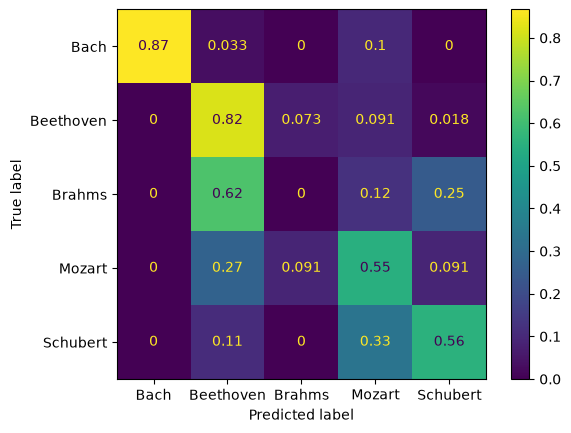

In [ ]:
metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

## Kernelized SVM

RBF SVM može da modeluje nelinearne granice između kompozitora.

Ovdje se podešavaju dva ključna hiperparametra:

- `C` kontroliše kompromis između šire margine i kažnjavanja grešaka;
- `gamma` određuje koliko lokalno djeluje RBF kernel — velika `gamma` pravi složenije/lokalnije granice,
  dok mala `gamma` daje glađu granicu.

Pošto SVM zavisi od skale atributa, `StandardScaler` je dio pipeline-a.


# Kernelized SVM

### SVM grid search

Za svaku kombinaciju `(C, gamma)` radi se isti 5-fold `StratifiedGroupKFold`, koristi se work-level majority
vote i pamte srednji accuracy i macro F1. Najbolja kombinacija se opet bira prema macro F1.

U sačuvanom tuningu najbolji rezultat je prijavljen za `C=10`, `gamma=0.001`, sa prosječnim macro F1 oko
**0.568**.


In [ ]:
import time
from sklearn.svm import SVC

C_values = [10 ** i for i in range(-1, 3)]
gamma_values = [0.001, 0.005, 0.01, 0.1]

results = []

grid_start_time = time.time()

for C in C_values:
    for gamma in gamma_values:

        work_acc_scores = []
        work_f1_scores = []

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X,y,groups),
            start = 1
        ):
            X_train_fold = X[train_idx]
            y_train_fold = y[train_idx]
            groups_train = groups[train_idx]

            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]

            groups_val = groups[val_idx]

            sample_weights = make_sample_weights(
                y_train_fold,
                groups_train
            )

            model = make_pipeline(
                preprocessing.StandardScaler(),

                SVC(
                    kernel = 'rbf',
                    C = C,
                    gamma = gamma,
                    class_weight = None
                )
            )

            model.fit(
                X_train_fold,
                y_train_fold,
                svc__sample_weight = sample_weights
            )

            pred = model.predict(X_val_fold)

            work_true, work_pred = majority_vote_prediction(
                y_val_fold,
                pred,
                groups_val
            )

            work_accuracy = metrics.accuracy_score(
                work_true,
                work_pred
            )

            work_f1 = metrics.f1_score(
                work_true,
                work_pred,
                average = "macro"
            )

            work_acc_scores.append(work_accuracy)
            work_f1_scores.append(work_f1)

        mean_acc = np.mean(work_acc_scores)
        mean_f1 = np.mean(work_f1_scores)

        results.append(
            (C,gamma,mean_acc,mean_f1)
        )

        print(
            f"C={C}, gamma={gamma}: "
            f"accuracy={mean_acc:.4f}, "
            f"macro_f1={mean_f1:.4f}"
        )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nSVM grid search ({len(C_values)} C values x {len(gamma_values)} gamma values x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)

C=0.1, gamma=0.001: accuracy=0.5233, macro_f1=0.4844
C=0.1, gamma=0.005: accuracy=0.6463, macro_f1=0.5875
C=0.1, gamma=0.01: accuracy=0.6903, macro_f1=0.6135
C=0.1, gamma=0.1: accuracy=0.0878, macro_f1=0.0318
C=1, gamma=0.001: accuracy=0.7088, macro_f1=0.6248
C=1, gamma=0.005: accuracy=0.7523, macro_f1=0.5584
C=1, gamma=0.01: accuracy=0.7611, macro_f1=0.5355
C=1, gamma=0.1: accuracy=0.4873, macro_f1=0.1310
C=10, gamma=0.001: accuracy=0.7705, macro_f1=0.5964
C=10, gamma=0.005: accuracy=0.7792, macro_f1=0.5514
C=10, gamma=0.01: accuracy=0.7436, macro_f1=0.4577
C=10, gamma=0.1: accuracy=0.4873, macro_f1=0.1310
C=100, gamma=0.001: accuracy=0.7705, macro_f1=0.5876
C=100, gamma=0.005: accuracy=0.7709, macro_f1=0.5468
C=100, gamma=0.01: accuracy=0.7436, macro_f1=0.4577
C=100, gamma=0.1: accuracy=0.4873, macro_f1=0.1310

SVM grid search (4 C values x 4 gamma values x 5 folds) trajao: 291.4s


In [ ]:
best = max(
    results,
    key=lambda x: x[3]
)

print("\nBest C:", best[0])
print("Best gamma:", best[1])
print("Best accuracy:", best[2])
print("Best macro F1:", best[3])


Best C: 1
Best gamma: 0.001
Best accuracy: 0.7087615283267457
Best macro F1: 0.6247993987436711


### SVM — završni izvještaj u ovom notebooku

Ova ćelija pravi objedinjeni classification report preko svih validacionih djela.

I ovdje postoji razlika između tuninga i izvještaja: finalna ćelija koristi `C=100`, `gamma=0.001` i
`class_weight="balanced"`, dok je tuning iznad kao najbolju kombinaciju ispisao `C=10`, `gamma=0.001`
i tokom tuninga koristio `sample_weight`.

Zato rezultate treba čitati kao rezultat **ove konkretne hardkodirane konfiguracije**, a ne kao strogo
finalnu evaluaciju `best` konfiguracije. Sačuvani output daje približno **0.70 accuracy** i **0.52 macro F1**.


In [ ]:
all_work_true = []
all_work_pred = []

work_acc_scores = []
work_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X, y, groups),
    start=1
):
    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]

    X_val_fold = X[val_idx]
    y_val_fold = y[val_idx]

    groups_val = groups[val_idx]

    model = make_pipeline(
        preprocessing.StandardScaler(),
        SVC(
            kernel="rbf",
            C=100,
            gamma=0.001,
            class_weight="balanced"
        )
    )

    model.fit(X_train_fold, y_train_fold)

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    work_acc_scores.append(
        metrics.accuracy_score(work_true, work_pred)
    )

    work_f1_scores.append(
        metrics.f1_score(
            work_true,
            work_pred,
            average="macro"
        )
    )

In [ ]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.93      0.97        30
   Beethoven       0.76      0.87      0.81        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.42      0.45      0.43        11
    Schubert       1.00      0.56      0.71         9

    accuracy                           0.76       113
   macro avg       0.64      0.56      0.59       113
weighted avg       0.76      0.76      0.75       113

Overall work accuracy: 0.7610619469026548
Overall work macro F1: 0.5856289772789152


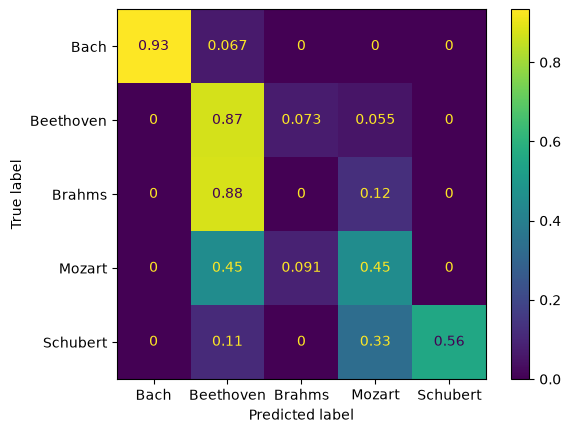

In [ ]:
from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

---

## Pokušaj popravljanja modela: balansiranje i soft voting

Ovaj dio uvodi dvije ideje:

1. `make_sample_weights` — ponderisanje trening segmenata da brojna djela/kompozitori ne dominiraju;
2. `soft_vote_predictions` — umjesto glasanja po konačnim klasama, prosječe se vjerovatnoće segmenata
   jednog djela, pa se bira klasa sa najvećom prosječnom vjerovatnoćom.

Soft voting može da iskoristi i "koliko je model siguran", dok majority voting vidi samo konačnu klasu
svakog segmenta.

U trenutnom notebooku je `soft_vote_predictions` definisana, ali se u modelima ispod ne koristi.


# Popravljanje modela

### Kako radi `make_sample_weights`

Za svaki segment se računa težina

`1 / (broj djela tog kompozitora × broj segmenata tog djela)`.

Time:

- djelo sa mnogo segmenata ne dobija automatski mnogo veći uticaj;
- kompozitor sa mnogo djela ne dominira samo zato što je zastupljeniji.

Na kraju se težine reskaluju tako da im je prosjek približno 1 (`sum(weights) = len(weights)`), što čuva
razumnu skalu optimizacionog problema.


## KNN

KNN nema klasičnu fazu učenja parametara: za novi segment traži najbliže trening segmente i glasanje
zasniva na njihovim klasama.

Ispituju se:

- `k = 3, 5, 7`;
- `weights="uniform"` — svi susjedi jednako glasaju;
- `weights="distance"` — bliži susjedi imaju veći uticaj.

`StandardScaler` je posebno bitan kod KNN-a zato što se udaljenosti računaju direktno iz atributa.
U sačuvanom outputu najbolji macro F1 je oko **0.433** za `k=3, weights="distance"`.


# KNN

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier

k_values = [3,5,7]
weight_values = ["uniform", "distance"]

results_knn = []

grid_start_time = time.time()

for k in k_values:
    for weight_type in weight_values:
        work_acc_scores = []
        work_f1_scores = []

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X,y,groups),
            start = 1
        ):
            X_train_fold = X[train_idx]
            y_train_fold = y[train_idx]

            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]
            groups_val = groups[val_idx]

            model = make_pipeline(
                preprocessing.StandardScaler(),

                KNeighborsClassifier(
                    n_neighbors=k,
                    weights=weight_type,
                    metric="minkowski",
                    p=2
                )
            )

            model.fit(
                X_train_fold,
                y_train_fold
            )

            pred = model.predict(X_val_fold)

            work_true, work_pred = majority_vote_prediction(
                y_val_fold,
                pred,
                groups_val
            )

            work_accuracy = metrics.accuracy_score(
                work_true,
                work_pred
            )

            work_f1 = metrics.f1_score(
                work_true,
                work_pred,
                average = "macro"
            )

            work_acc_scores.append(work_accuracy)
            work_f1_scores.append(work_f1)

        mean_acc = np.mean(work_acc_scores)
        mean_f1 = np.mean(work_f1_scores)

        results_knn.append(
            (k, weight_type, mean_acc, mean_f1)
        )

        print(
            f"k={k}, weights={weight_type}: "
            f"accuracy={mean_acc:.4f}, "
            f"macro_f1={mean_f1:.4f}"
        )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nKNN grid search ({len(k_values)} k values x {len(weight_values)} weight types x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)

k=3, weights=uniform: accuracy=0.7168, macro_f1=0.3625
k=3, weights=distance: accuracy=0.7175, macro_f1=0.3673
k=5, weights=uniform: accuracy=0.7259, macro_f1=0.3668
k=5, weights=distance: accuracy=0.7168, macro_f1=0.3623
k=7, weights=uniform: accuracy=0.7168, macro_f1=0.3612
k=7, weights=distance: accuracy=0.7168, macro_f1=0.3612

KNN grid search (3 k values x 2 weight types x 5 folds) trajao: 9.7s


In [ ]:
best_knn = max(
    results_knn,
    key=lambda x: x[3]
)

print(best_knn)

(3, 'distance', np.float64(0.7175230566534914), np.float64(0.3672891552891553))


## Random Forest Classifier

Random Forest gradi veliki broj decision tree modela i kombinuje njihove predikcije. Za razliku od
Logistic Regression, SVM i KNN-a, ovdje standardizacija atributa nije potrebna.

Grid search ispituje:

- `n_estimators` — broj stabala;
- `max_depth` — maksimalnu dubinu stabla;
- `min_samples_leaf` — minimalan broj trening primjera u listu.

`max_features="sqrt"` znači da svako cijepanje razmatra samo slučajan podskup atributa, što povećava
raznolikost stabala. `n_jobs=-1` koristi sva dostupna CPU jezgra.


# Random Forest Classifer

In [ ]:
from sklearn.ensemble import RandomForestClassifier

### Random Forest — tuning

Za svaku kombinaciju hiperparametara koristi se isti group-aware 5-fold postupak i `sample_weight`.
Na osnovu sačuvanog outputa najbolji macro F1 u ovom gridu je približno **0.596** za
`n_estimators=300`, `max_depth=10`, `min_samples_leaf=1`.

Sljedeća ćelija upravo tu konfiguraciju koristi za objedinjeni classification report.


In [ ]:
import time

n_estimators_values = [300, 500]
max_depth_values = [None, 10, 20]
min_samples_leaf_values = [1, 2, 4]

results_rf = []

grid_start_time = time.time()

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_leaf in min_samples_leaf_values:

            work_acc_scores = []
            work_f1_scores = []

            for fold, (train_idx, val_idx) in enumerate(
                sgkf.split(X, y, groups),
                start=1
            ):
                X_train_fold = X[train_idx]
                y_train_fold = y[train_idx]
                groups_train = groups[train_idx]

                X_val_fold = X[val_idx]
                y_val_fold = y[val_idx]
                groups_val = groups[val_idx]

                sample_weights = make_sample_weights(
                    y_train_fold,
                    groups_train
                )

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features="sqrt",
                    class_weight=None,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_fold,
                    y_train_fold,
                    sample_weight=sample_weights
                )

                pred = model.predict(
                    X_val_fold
                )

                work_true, work_pred = majority_vote_prediction(
                    y_val_fold,
                    pred,
                    groups_val
                )

                work_accuracy = metrics.accuracy_score(
                    work_true,
                    work_pred
                )

                work_f1 = metrics.f1_score(
                    work_true,
                    work_pred,
                    average="macro"
                )

                work_acc_scores.append(work_accuracy)
                work_f1_scores.append(work_f1)

            mean_acc = np.mean(work_acc_scores)
            mean_f1 = np.mean(work_f1_scores)

            results_rf.append(
                (
                    n_estimators,
                    max_depth,
                    min_samples_leaf,
                    mean_acc,
                    mean_f1
                )
            )

            print(
                f"trees={n_estimators}, "
                f"depth={max_depth}, "
                f"leaf={min_samples_leaf}: "
                f"accuracy={mean_acc:.4f}, "
                f"macro_f1={mean_f1:.4f}"
            )

grid_elapsed = time.time() - grid_start_time
n_combos = len(n_estimators_values) * len(max_depth_values) * len(min_samples_leaf_values)
print(
    f"\nRandom Forest grid search ({n_combos} kombinacija x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)

trees=300, depth=None, leaf=1: accuracy=0.7785, macro_f1=0.5613
trees=300, depth=None, leaf=2: accuracy=0.7963, macro_f1=0.6040
trees=300, depth=None, leaf=4: accuracy=0.7959, macro_f1=0.6307
trees=300, depth=10, leaf=1: accuracy=0.7872, macro_f1=0.6246
trees=300, depth=10, leaf=2: accuracy=0.7694, macro_f1=0.5903
trees=300, depth=10, leaf=4: accuracy=0.7781, macro_f1=0.6244
trees=300, depth=20, leaf=1: accuracy=0.7785, macro_f1=0.5613
trees=300, depth=20, leaf=2: accuracy=0.7963, macro_f1=0.6040
trees=300, depth=20, leaf=4: accuracy=0.7959, macro_f1=0.6256
trees=500, depth=None, leaf=1: accuracy=0.7785, macro_f1=0.5613
trees=500, depth=None, leaf=2: accuracy=0.7963, macro_f1=0.6040
trees=500, depth=None, leaf=4: accuracy=0.8050, macro_f1=0.6455
trees=500, depth=10, leaf=1: accuracy=0.7872, macro_f1=0.6246
trees=500, depth=10, leaf=2: accuracy=0.7872, macro_f1=0.6246
trees=500, depth=10, leaf=4: accuracy=0.7698, macro_f1=0.6153
trees=500, depth=20, leaf=1: accuracy=0.7694, macro_f1=0.5

### Random Forest — objedinjena evaluacija

Svako djelo je tačno jednom u validacionom dijelu jednog folda. Predikcije se sabiraju u `all_work_true`
i `all_work_pred`, pa završni report predstavlja out-of-fold rezultate na ukupno 113 djela.

Sačuvani rezultat je približno:

- **accuracy = 0.77**
- **macro F1 = 0.63**

Od prikazanih klasičnih modela u ovom notebooku Random Forest daje najjači sačuvani work-level rezultat,
posebno u odnosu na Logistic Regression i KNN. Ipak, manjinske klase i dalje imaju znatno manje podataka,
pa je macro F1 važniji pokazatelj od samog accuracy-ja.


In [ ]:
all_work_true = []
all_work_pred = []
all_importances = []

for train_idx, val_idx in sgkf.split(X, y, groups):

    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]
    groups_train = groups[train_idx]

    X_val_fold = X[val_idx]
    y_val_fold = y[val_idx]
    groups_val = groups[val_idx]

    sample_weights = make_sample_weights(
        y_train_fold,
        groups_train
    )

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        sample_weight=sample_weights
    )

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)
    all_importances.append(model.feature_importances_)

In [ ]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.90      0.95        30
   Beethoven       0.80      0.87      0.83        55
      Brahms       0.43      0.38      0.40         8
      Mozart       0.46      0.55      0.50        11
    Schubert       0.83      0.56      0.67         9

    accuracy                           0.79       113
   macro avg       0.70      0.65      0.67       113
weighted avg       0.80      0.79      0.79       113



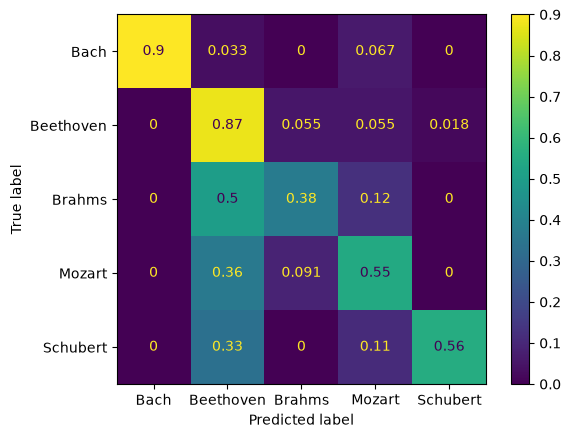

In [ ]:
metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

### Feature importance (Random Forest)

Pošto sad imamo 147 atributa na svega ~113 djela, korisno je provjeriti koje atribute model stvarno
koristi prije nego što se doda još njih (ili prije nego posumnjamo da neki dodati atribut kvari rezultat).

`feature_importances_` iz svakog od 5 RF modela (istreniranih iznad, po foldu) se usrednjava — tako
importance nije vezan za samo jedan slučajan split. Koristi se Gini/impurity-based importance ugrađen u
`RandomForestClassifier`; nije savršena mjera (blago favorizuje kontinualne/visoko-kardinalne atribute), ali
je besplatna nuspojava treninga koji već radimo i dovoljno dobra za orijentaciju.

Ako se pokaže da npr. cijeli blok delta-MFCC ili tonnetz atributa ima importance blizu nule, to je signal da
se ti atributi mogu izbaciti bez gubitka performansi — manje dimenzija je manje rizika od overfittinga na
ovako malom skupu.


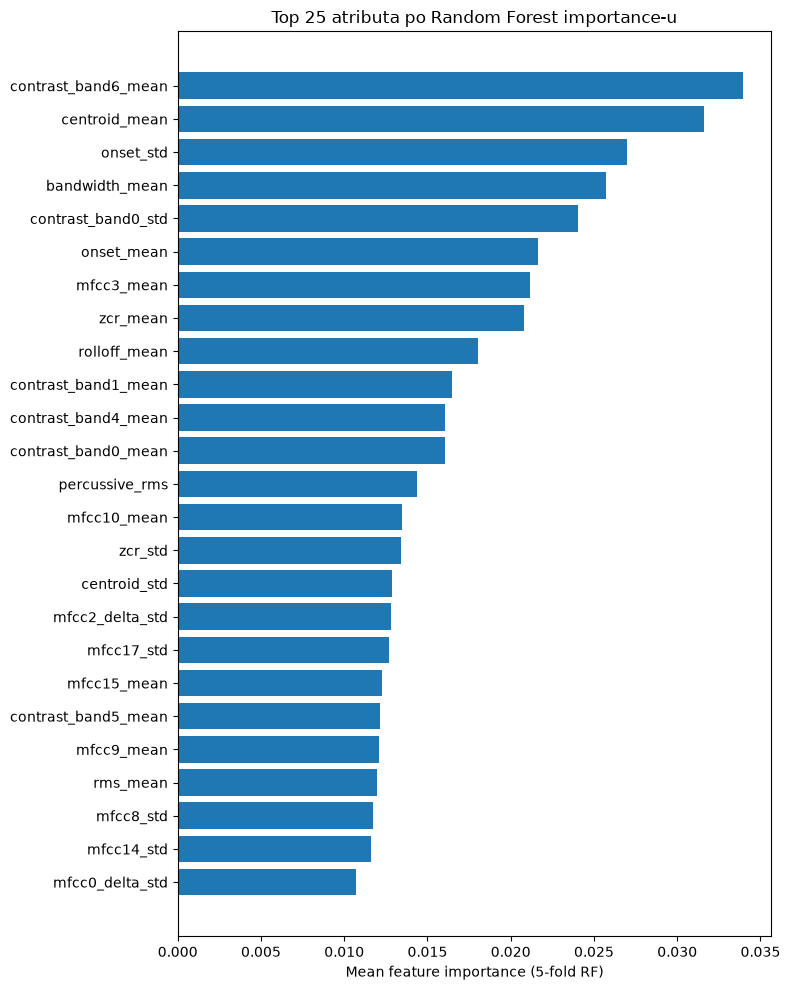

In [ ]:
from src.features.feature_engineering import feature_names

names = feature_names()

mean_importance = np.mean(all_importances, axis=0)

order = np.argsort(mean_importance)[::-1]

top_n = 25

top_idx = order[:top_n]

plt.figure(figsize=(8, 10))
plt.barh(
    [names[i] for i in top_idx][::-1],
    mean_importance[top_idx][::-1]
)
plt.xlabel("Mean feature importance (5-fold RF)")
plt.title(f"Top {top_n} atributa po Random Forest importance-u")
plt.tight_layout()
plt.show()

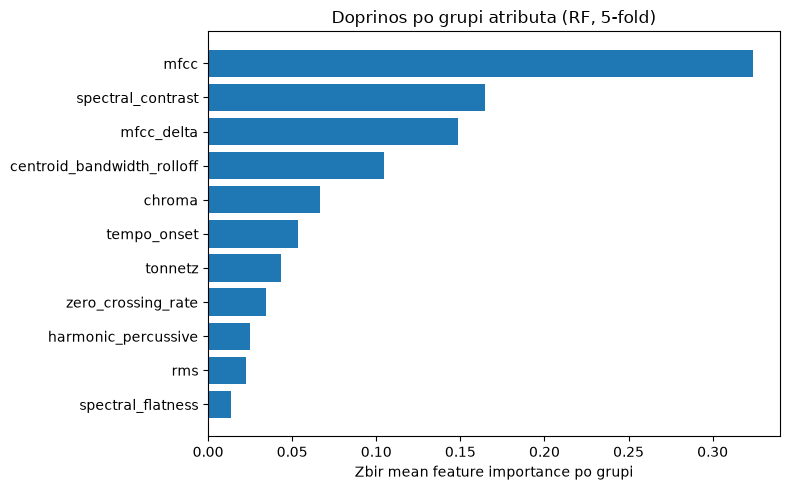

In [ ]:
def feature_group(name):
    if name.startswith("mfcc") and "delta" in name:
        return "mfcc_delta"
    if name.startswith("mfcc"):
        return "mfcc"
    if name.startswith("chroma"):
        return "chroma"
    if name.startswith("tonnetz"):
        return "tonnetz"
    if name.startswith("contrast"):
        return "spectral_contrast"
    if name.startswith("flatness"):
        return "spectral_flatness"
    if name.startswith("zcr"):
        return "zero_crossing_rate"
    if name.startswith("rms"):
        return "rms"
    if name in ("tempo", "onset_mean", "onset_std"):
        return "tempo_onset"
    if name in ("harmonic_ratio", "percussive_rms"):
        return "harmonic_percussive"
    return "centroid_bandwidth_rolloff"


groups_importance = {}

for name, importance in zip(names, mean_importance):
    group = feature_group(name)
    groups_importance[group] = groups_importance.get(group, 0.0) + importance

group_order = sorted(
    groups_importance.items(),
    key=lambda item: item[1],
    reverse=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    [g for g, _ in group_order][::-1],
    [v for _, v in group_order][::-1]
)
plt.xlabel("Zbir mean feature importance po grupi")
plt.title("Doprinos po grupi atributa (RF, 5-fold)")
plt.tight_layout()
plt.show()

---

## XGBoost

Gradient boosting ansambl — stabla se dodaju sekvencijalno, svako ispravlja greške prethodnih. Često
nadmaši Random Forest na ovakvim tabelarnim feature setovima. `LabelEncoder` je potreban jer XGBoost
očekuje numeričke labele, ne stringove.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y)

all_work_true = []
all_work_pred = []

for train_idx, val_idx in sgkf.split(X, y, groups):
    X_train_fold = X[train_idx]
    y_train_fold = le.transform(y[train_idx])
    groups_train = groups[train_idx]

    X_val_fold = X[val_idx]
    y_val_fold = y[val_idx]
    groups_val = groups[val_idx]

    sample_weights = make_sample_weights(y[train_idx], groups_train)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

    pred = le.inverse_transform(model.predict(X_val_fold))

    work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

print(metrics.classification_report(all_work_true, all_work_pred))

---

# Kratak rezime notebooka

Ako neko želi samo da razumije logiku bez ulaska u svaki detalj koda, glavna priča je:

**audio zapis → segmenti → audio atributi → group-aware cross-validation → predikcija svakog segmenta →
majority vote po djelu → work-level accuracy i macro F1.**

Najvažnija metodološka odluka je da se split radi po `work_id`, jer to sprečava data leakage između
segmenata istog muzičkog djela.

Na sačuvanim outputima približni rezultati su:

| Model | Work accuracy | Macro F1 | Napomena |
|---|---:|---:|---|
| Logistic Regression | 0.59 | 0.46 | završna ćelija ne koristi identičnu konfiguraciju kao tuning |
| RBF SVM | 0.70 | 0.52 | završna ćelija se razlikuje od `best` tuning konfiguracije |
| KNN | 0.73* | 0.43* | vrijednosti su srednji CV rezultat iz tuninga |
| Random Forest | 0.77 | 0.63 | najbolji sačuvani završni report |

`*` KNN nema poseban objedinjeni classification report u prikazanom notebooku.

## Tri stvari na koje posebno obratiti pažnju

1. **Ne miješati segment-level i work-level evaluaciju.** Konačna metrika ovdje treba da opisuje djela.
2. **Macro F1 je bitan zbog neravnoteže klasa.** Visok accuracy može da sakrije loš rezultat na Brahmsu,
   Mozartu ili Schubertu.
3. **Novi `extract_features` na kraju još nije primijenjen na postojeći `X`.** Za novi eksperiment mora se
   regenerisati dataset.
